In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('/content/drive/MyDrive/Deep Learning/Lecture 1-10/placement.csv')

In [4]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [5]:
X=df.drop(columns=['placement'])
y=df['placement']

<Axes: xlabel='cgpa', ylabel='placement'>

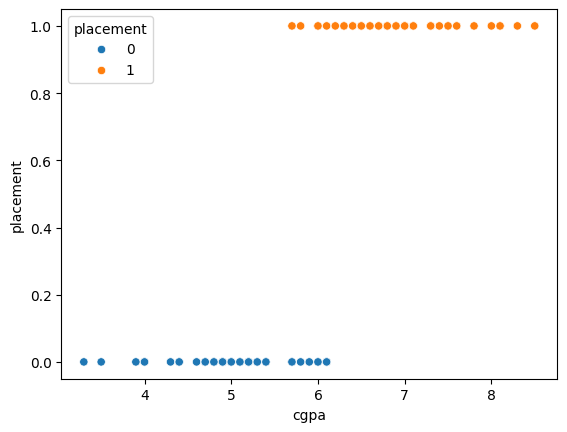

In [6]:
sns.scatterplot(x='cgpa',y='placement',data=df,hue=df['placement'])

In [7]:
from sklearn.linear_model import Perceptron
p=Perceptron()

In [8]:
p.fit(X,y)

Perceptron()

In [9]:
p.coef_
# value of weights = [[-39., 688., -75.]]

array([[-39., 688., -75.]])

In [10]:
p.intercept_
# value for the slope

array([-12.])

In [12]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

In [13]:
import matplotlib.pyplot as plt

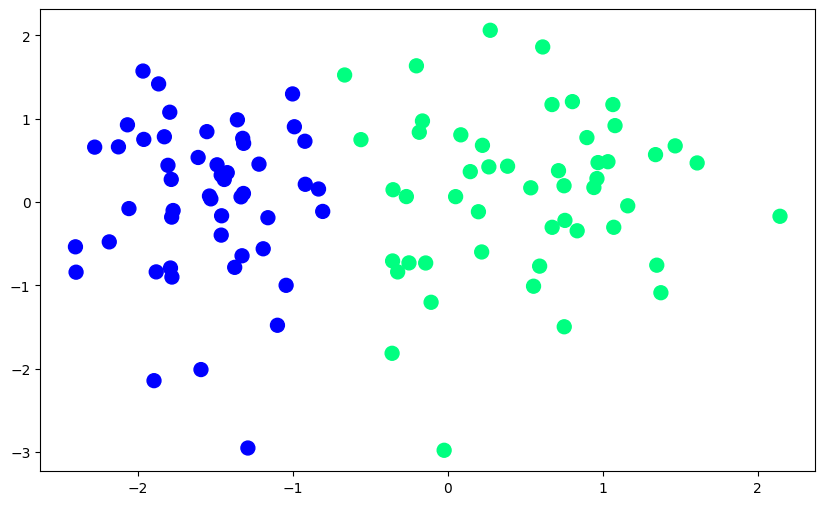

In [14]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [15]:
def perceptron(X,y):

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]

    return weights[0],weights[1:]


In [16]:
def step(z):
    return 1 if z>0 else 0

In [17]:
intercept_,coef_ = perceptron(X,y)

In [20]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

# what is this ?
# y=mx+b
# m=-a/b;
# b=-c/b;

In [21]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

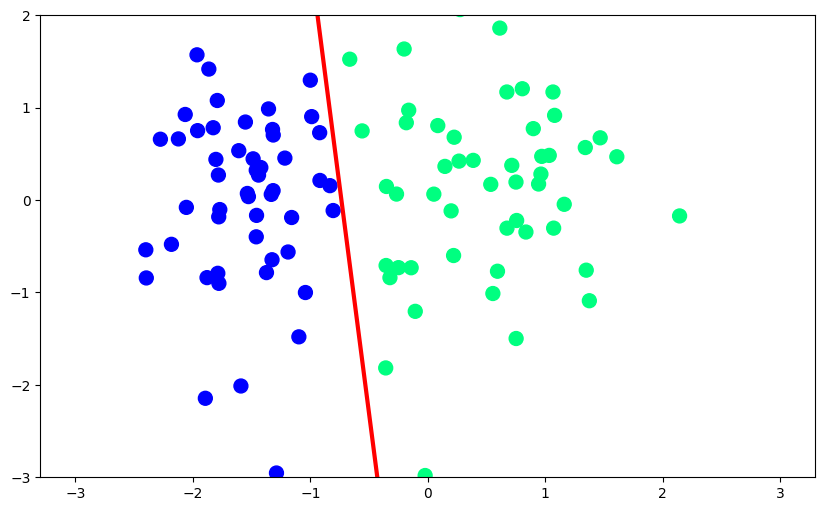

In [22]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

above we found the line from the perceptron trick but now we will find it using log loss function gradient descent curve ...

In [23]:
X.shape

(100, 2)

In [24]:
y

array([1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

In [32]:
def perceptron(X,y):
  w1=w2=b=1
  lr=0.1

  for i in range(X[0].shape):
    z=w1*X[i][0]+w2*x[i][1]+b

    if z*y[i]<0:
      w1 = w1 + lr*y[i]*X[i][0]
      w2 = w2 + lr*y[i]*X[i][1]
      b = b + lr*y[i]

  return w1,w2,b


In [37]:
def perceptron(X,y):
  w1=w2=b=1
  lr=0.1

  # Fixed: Iterate over the number of samples (rows) in X
  for i in range(X.shape[0]):
    # Fixed: x[i][1] should be X[i][1]
    z=w1*X[i][0]+w2*X[i][1]+b

    if z*y[i]<0:
      w1 = w1 + lr*y[i]*X[i][0]
      w2 = w2 + lr*y[i]*X[i][1]
      b = b + lr*y[i]

  return w1,w2,b

w1,w2,b = perceptron(X,y)

In [34]:
b

np.float64(-7.212450620310209)

In [38]:
m = -(w1/w2)
c = -(b/w2)

print(m,c)

-2.061677716827141 -2.892533228525769


(-3.0, 2.0)

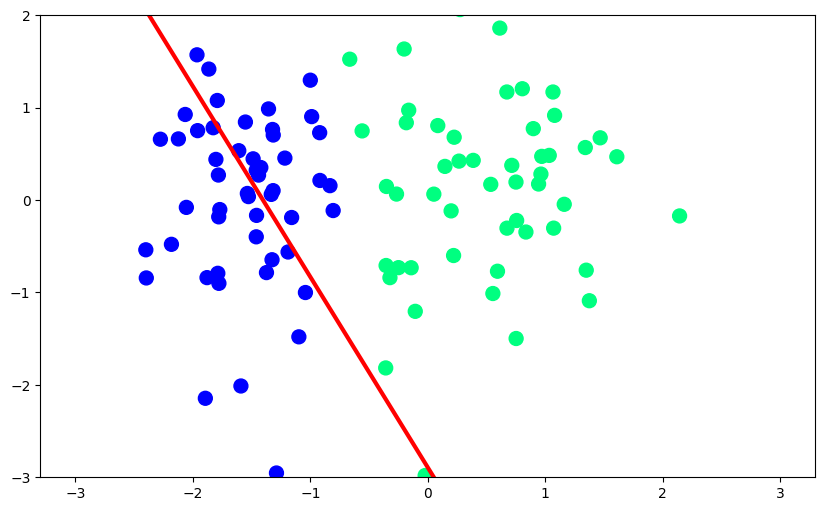

In [39]:
x_input = np.linspace(-3,3,100) # Generates 100 evenly spaced numbers between -3 and 3
y_input = m*x_input + c

plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)